# Worksheet 7 - Detecting Overfitting, Applying Regularization and Cross Validation

**Module:** 5CS037 - Concepts and Technologies of AI  
**Student Name:** Ujwal Shrestha  

---

## 1. Instructions
This worksheet contains exercises on Linear Regression and Logistic Regression using Scikit-learn with L1/L2 regularization, cross-validation, and hyperparameter tuning.

**Objectives:**
*   Observe and report the effect of regularization and hyperparameter tuning on model performance.
*   Use Scikit-learn for all implementations.


In [36]:
# Universal Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn Imports
from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score

import kagglehub

import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

---
## 3. Part 1: Regression Task (California Housing)

### 3.1 Task 1: Load and Split Dataset
We will load the California Housing dataset and split it into 80% training and 20% testing sets.

In [37]:
import os

path = kagglehub.dataset_download("camnugent/california-housing-prices")

housing_data = pd.read_csv(os.path.join(path, "housing.csv"))

housing_data.head()

Using Colab cache for faster access to the 'california-housing-prices' dataset.


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


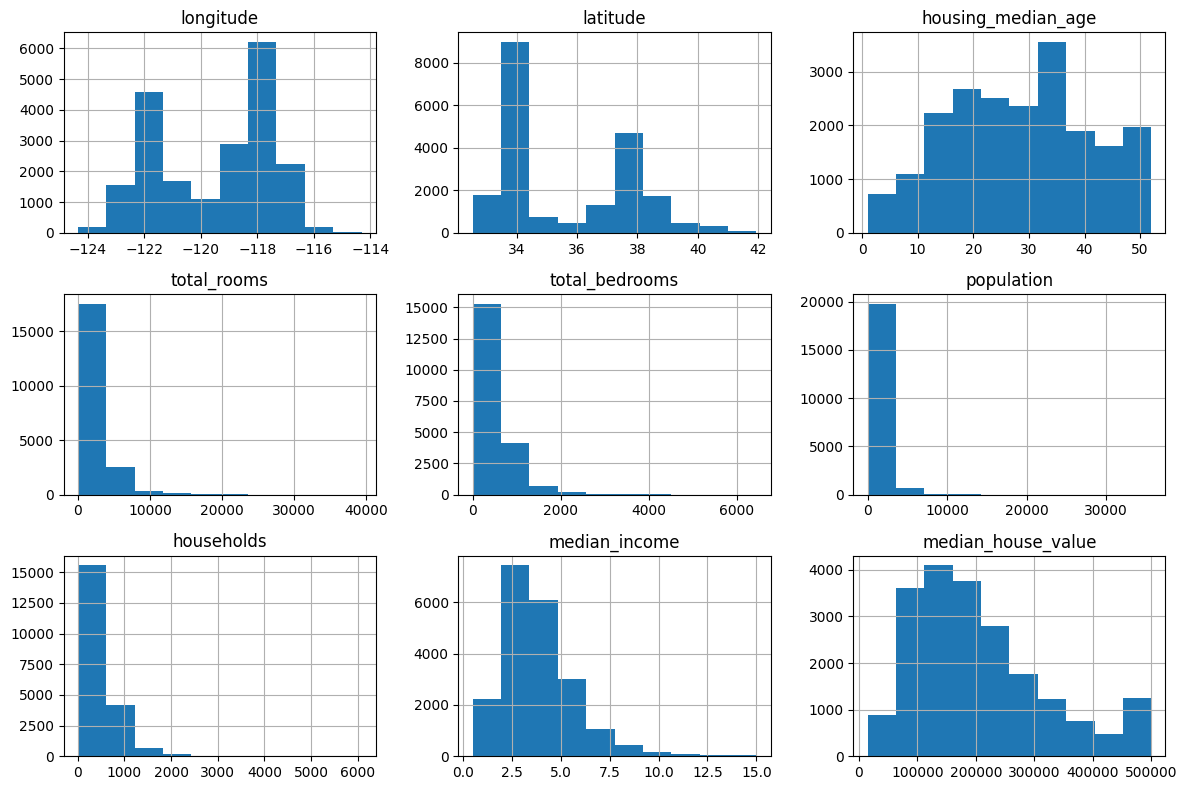

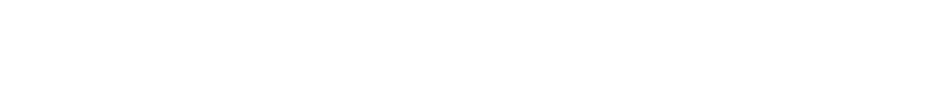

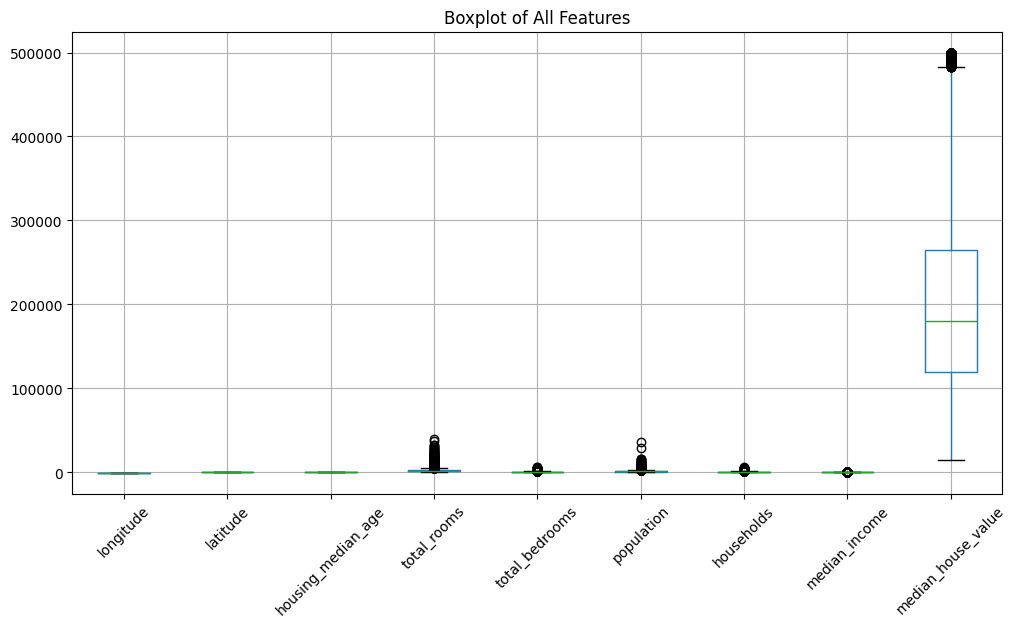

In [38]:
# Histogram
housing_data.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 1))
plt.axis('off')
plt.show()

# Boxplot
plt.figure(figsize=(12, 6))
housing_data.boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of All Features")
plt.show()


In [39]:
categorical_cols = housing_data.select_dtypes(include=["object"]).columns
print(categorical_cols)

housing_model_data = pd.get_dummies(housing_data, columns=categorical_cols)
print(f"Housing Data after procesing(Front 5 rows): \n{housing_model_data.head()}\n")

print("=" * 100)
print(f"\nHousing Data after procesing(Last 5 rows): \n{housing_model_data.tail()}")

Index(['ocean_proximity'], dtype='object')
Housing Data after procesing(Front 5 rows): 
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  \
0       322.0       126.0         8.3252            452600.0   
1      2401.0      1138.0         8.3014            358500.0   
2       496.0       177.0         7.2574            352100.0   
3       558.0       219.0         5.6431            341300.0   
4       565.0       259.0         3.8462            342200.0   

   ocean_proximity_<1H OCEAN  ocean_proximity_INLAND  ocean_proximity_ISLAND

In [40]:

features = housing_model_data.drop("median_house_value", axis=1)
target = housing_model_data["median_house_value"]

# Split the dataset
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(features, target, test_size=0.2, random_state=42)
#Outputs:

print(X_train_h.shape)
print(X_test_h.shape)
print(y_train_h.shape)
print(y_test_h.shape)

(16512, 13)
(4128, 13)
(16512,)
(4128,)


In [41]:
# Drop rows with NaN in training and test sets
X_train_h_clean = X_train_h.dropna()
y_train_h_clean = y_train_h[X_train_h_clean.index]

X_test_h_clean = X_test_h.dropna()
y_test_h_clean = y_test_h[X_test_h_clean.index]


### 3.2 Task 2: Linear Regression, Regularization & Tuning

#### Step 1: Baseline Model (No Regularization)
Building a Linear Regression model without any regularization to serve as a baseline.

In [42]:
# Initialize and train the baseline model
baseline_lr = LinearRegression()
baseline_lr.fit(X_train_h_clean, y_train_h_clean)

# Predict on training and test sets
y_train_pred_h = baseline_lr.predict(X_train_h_clean)
y_test_pred_h = baseline_lr.predict(X_test_h_clean)

# Compute MSE
mse_train_base = mean_squared_error(y_train_h_clean, y_train_pred_h)
mse_test_base = mean_squared_error(y_test_h_clean, y_test_pred_h)

print("Baseline Linear Regression Results:")
print(f"Training MSE: {mse_train_base:.4f}")
print(f"Test MSE: {mse_test_base:.4f}")
print("Coefficients:", baseline_lr.coef_)

Baseline Linear Regression Results:
Training MSE: 4683203783.5043
Test MSE: 4830748295.7922
Coefficients: [-2.68382734e+04 -2.54683520e+04  1.10218508e+03 -6.02150567e+00
  1.02789395e+02 -3.81729064e+01  4.82527528e+01  3.94739752e+04
 -1.89265829e+04 -5.87132390e+04  1.17198490e+05 -2.40632251e+04
 -1.54954428e+04]


#### Step 2: Hyperparameter Tuning
Using `GridSearchCV` to find the optimal alpha for Ridge (L2) and Lasso (L1) regression.

In [43]:
# Define alpha values to test
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# Ridge Regression Tuning
ridge_grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train_h, y_train_h)

best_ridge = ridge_grid.best_estimator_
best_ridge_alpha = ridge_grid.best_params_['alpha']

print(f"Best Ridge Alpha: {best_ridge_alpha}")
print(f"Best Ridge CV Score (MSE): {-ridge_grid.best_score_:.4f}")

# Lasso Regression Tuning
lasso_grid = GridSearchCV(Lasso(), param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train_h, y_train_h)

best_lasso = lasso_grid.best_estimator_
best_lasso_alpha = lasso_grid.best_params_['alpha']

print(f"Best Lasso Alpha: {best_lasso_alpha}")
print(f"Best Lasso CV Score (MSE): {-lasso_grid.best_score_:.4f}")

Best Ridge Alpha: 1
Best Ridge CV Score (MSE): 4711059529.9454
Best Lasso Alpha: 0.001
Best Lasso CV Score (MSE): 4711122401.8972


#### Step 3: Regularization Experiments (L1 vs L2)
Evaluating the tuned models on the test set and comparing their coefficients.

Tuned Model Performance (Test MSE):
Ridge (L2): 4831902545.1858
Lasso (L1): 4830748480.4255

Coefficient Comparison:
    Feature_Index       Baseline    Ridge (L2)     Lasso (L1)
0               0  -26838.273372 -26859.323675  -26838.279261
1               1  -25468.352050 -25493.549147  -25468.357895
2               2    1102.185084   1102.564544    1102.185250
3               3      -6.021506     -6.020789      -6.021506
4               4     102.789395    102.913149     102.789417
5               5     -38.172906    -38.175883     -38.172908
6               6      48.252753     48.117796      48.252735
7               7   39473.975175  39471.826278   39473.974985
8               8  -18926.582862 -14045.495230   16722.257933
9               9  -58713.239023 -53792.064430  -23064.388161
10             10  117198.489753  97624.781170  152843.192336
11             11  -24063.225079 -19167.973702   11585.602311
12             12  -15495.442789 -10619.247810   20153.385084


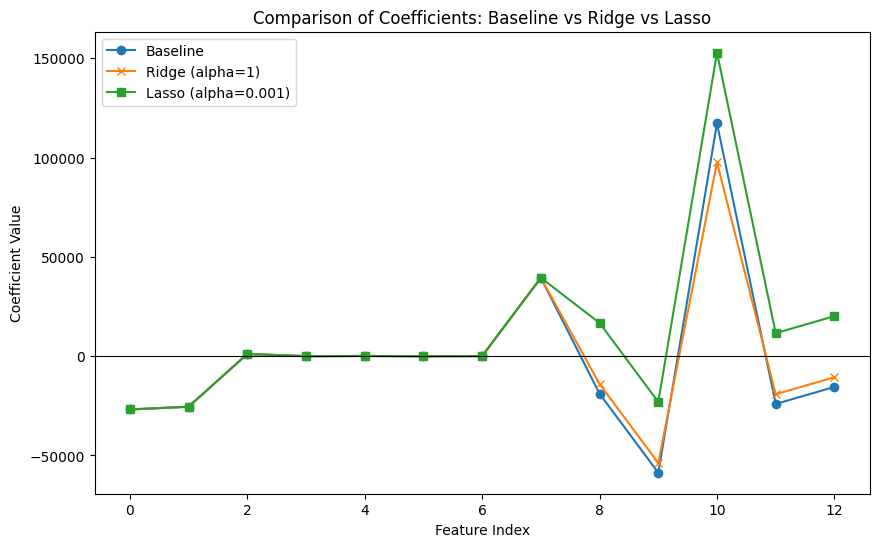

In [44]:
# Predict with tuned models
y_test_pred_ridge = best_ridge.predict(X_test_h_clean)
y_test_pred_lasso = best_lasso.predict(X_test_h_clean)

# Calculate Test MSE
mse_test_ridge = mean_squared_error(y_test_h_clean, y_test_pred_ridge)
mse_test_lasso = mean_squared_error(y_test_h_clean, y_test_pred_lasso)

print("Tuned Model Performance (Test MSE):")
print(f"Ridge (L2): {mse_test_ridge:.4f}")
print(f"Lasso (L1): {mse_test_lasso:.4f}")

# Compare coefficients
coef_df = pd.DataFrame({
    'Feature_Index': range(len(baseline_lr.coef_)),
    'Baseline': baseline_lr.coef_,
    'Ridge (L2)': best_ridge.coef_,
    'Lasso (L1)': best_lasso.coef_
})

print("\nCoefficient Comparison:")
print(coef_df)

# Visualization of Coefficients
plt.figure(figsize=(10, 6))
plt.plot(coef_df['Feature_Index'], coef_df['Baseline'], label='Baseline', marker='o')
plt.plot(coef_df['Feature_Index'], coef_df['Ridge (L2)'], label=f'Ridge (alpha={best_ridge_alpha})', marker='x')
plt.plot(coef_df['Feature_Index'], coef_df['Lasso (L1)'], label=f'Lasso (alpha={best_lasso_alpha})', marker='s')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title('Comparison of Coefficients: Baseline vs Ridge vs Lasso')
plt.legend()
plt.show()

#### **Discussion on Bias-Variance Tradeoff**
* L1 or Lasso regularization makes some coefficient go zero so it select feature automatically. This increase bias little bit but reduce variance a lot so model become simple.
* L2 or Ridge regularization does not make the coefficient zero but it shrink them near to zero and helps when all feature are important.
* If baseline model is overfitted with big coefficient and bad test score then regularization helps, but if alpha too high model become too simple and underfit occurs.

---
## 4 Part 2: Classification Task (Breast Cancer)

### 4.1 Task 1: Load and Split Dataset
Loading the Breast Cancer dataset and splitting it into 80% training and 20% testing.

In [45]:
# Load Breast Cancer Dataset
X_cancer, y_cancer = load_breast_cancer(return_X_y=True)

# Split the dataset
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cancer, y_cancer, test_size=0.2, random_state=42)

print(f"Cancer Training shape: {X_train_c.shape}")
print(f"Cancer Testing shape: {X_test_c.shape}")

Cancer Training shape: (455, 30)
Cancer Testing shape: (114, 30)


### 4.2 Task 2: Logistic Regression, Regularization & Tuning

#### Step 1: Baseline Model (No explicit regularization settings)
We use the default `LogisticRegression`, which actually uses L2 regularization by default (C=1.0). We will treat this as our starting point.

In [46]:
# Initialize and train baseline model
baseline_log_reg = LogisticRegression(max_iter=10000)
baseline_log_reg.fit(X_train_c, y_train_c)

# Predict
y_train_pred_c = baseline_log_reg.predict(X_train_c)
y_test_pred_c = baseline_log_reg.predict(X_test_c)

# Accuracy
acc_train_base = accuracy_score(y_train_c, y_train_pred_c)
acc_test_base = accuracy_score(y_test_c, y_test_pred_c)

print("Baseline Logistic Regression Results:")
print(f"Training Accuracy: {acc_train_base:.4f}")
print(f"Test Accuracy: {acc_test_base:.4f}")

Baseline Logistic Regression Results:
Training Accuracy: 0.9582
Test Accuracy: 0.9561


#### Step 2: Hyperparameter Tuning
Focusing on tuning the `C` parameter (inverse of regularization strength) and `penalty` (l1 or l2).

In [47]:
# Define grid
param_grid_c = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Note: 'liblinear' solver supports both l1 and l2 regularization
log_reg_grid = GridSearchCV(LogisticRegression(solver='liblinear', max_iter=10000), param_grid_c, cv=5, scoring='accuracy')
log_reg_grid.fit(X_train_c, y_train_c)

best_log_reg = log_reg_grid.best_estimator_
best_params = log_reg_grid.best_params_

print(f"Best Parameters: {best_params}")
print(f"Best CV Accuracy: {log_reg_grid.best_score_:.4f}")

Best Parameters: {'C': 100, 'penalty': 'l1'}
Best CV Accuracy: 0.9670


#### Step 3: Regularization Experiments (L1 vs L2)
Training separate L1 and L2 models using the optimal `C` found (or examining the best estimator) to compare coefficients.

L1 Model (Lasso-like) Test Accuracy: 0.9825
L2 Model (Ridge-like) Test Accuracy: 0.9561

Number of zero coefficients in L1 model: 9
Number of zero coefficients in L2 model: 0


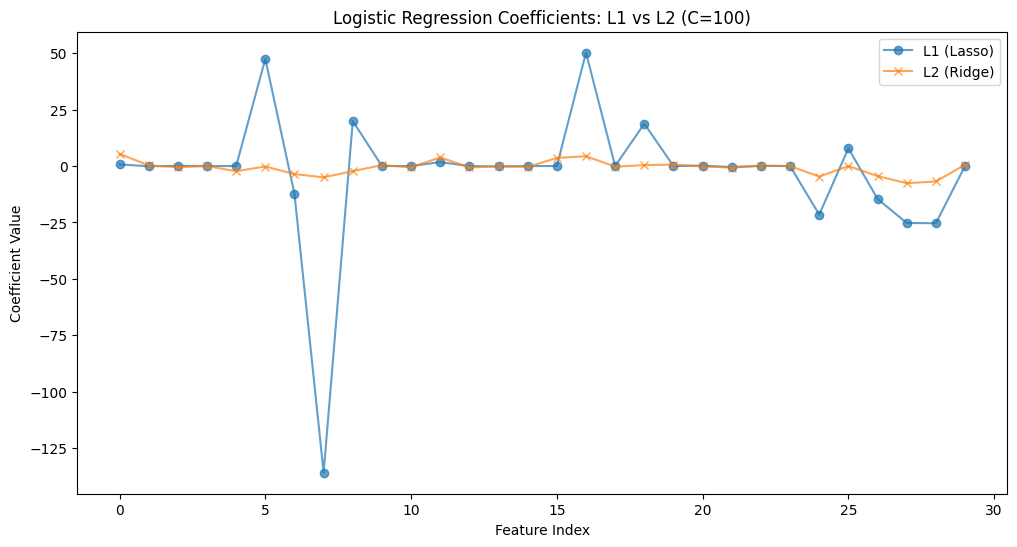

In [48]:
optimal_C = best_params['C']

# Train L1 Model
l1_model = LogisticRegression(C=optimal_C, penalty='l1', solver='liblinear', max_iter=10000)
l1_model.fit(X_train_c, y_train_c)

# Train L2 Model
l2_model = LogisticRegression(C=optimal_C, penalty='l2', solver='liblinear', max_iter=10000)
l2_model.fit(X_train_c, y_train_c)

# Evaluate
l1_acc = accuracy_score(y_test_c, l1_model.predict(X_test_c))
l2_acc = accuracy_score(y_test_c, l2_model.predict(X_test_c))

print(f"L1 Model (Lasso-like) Test Accuracy: {l1_acc:.4f}")
print(f"L2 Model (Ridge-like) Test Accuracy: {l2_acc:.4f}")

# Compare Sparsity
l1_zeros = np.sum(l1_model.coef_ == 0)
l2_zeros = np.sum(l2_model.coef_ == 0)

print(f"\nNumber of zero coefficients in L1 model: {l1_zeros}")
print(f"Number of zero coefficients in L2 model: {l2_zeros}")

# Visualization of coefficients (subset of features for clarity)
plt.figure(figsize=(12, 6))
plt.plot(l1_model.coef_.flatten(), label='L1 (Lasso)', marker='o', alpha=0.7)
plt.plot(l2_model.coef_.flatten(), label='L2 (Ridge)', marker='x', alpha=0.7)
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title(f'Logistic Regression Coefficients: L1 vs L2 (C={optimal_C})')
plt.legend()
plt.show()

#### **Discussion on Classifcation Regularization**

* L1 regularization makes the model sparse by setting some coefficients to zero, which helps in selecting the most important features and improves interpretability.
* L2 regularization usually works better when all features contribute a small amount, while L1 is more useful when only a few features are relevant.
* Stronger regularization (smaller C) reduces overfitting by lowering variance but increases bias, so GridSearchCV is used to find a good balance.